In [1]:
import pandas as pd
import polars as pl

In [2]:
import polars as pl

df_preview = pl.read_csv("/Users/eldanizarifzada/Downloads/NF-UQ-NIDS-v2.csv", n_rows=5)
print(df_preview)

shape: (5, 46)
┌────────────┬────────────┬────────────┬────────────┬───┬────────────┬───────┬────────┬────────────┐
│ IPV4_SRC_A ┆ L4_SRC_POR ┆ IPV4_DST_A ┆ L4_DST_POR ┆ … ┆ FTP_COMMAN ┆ Label ┆ Attack ┆ Dataset    │
│ DDR        ┆ T          ┆ DDR        ┆ T          ┆   ┆ D_RET_CODE ┆ ---   ┆ ---    ┆ ---        │
│ ---        ┆ ---        ┆ ---        ┆ ---        ┆   ┆ ---        ┆ i64   ┆ str    ┆ str        │
│ str        ┆ i64        ┆ str        ┆ i64        ┆   ┆ f64        ┆       ┆        ┆            │
╞════════════╪════════════╪════════════╪════════════╪═══╪════════════╪═══════╪════════╪════════════╡
│ 192.168.10 ┆ 65389      ┆ 192.168.10 ┆ 80         ┆ … ┆ 0.0        ┆ 1     ┆ DoS    ┆ NF-BoT-IoT │
│ 0.148      ┆            ┆ 0.7        ┆            ┆   ┆            ┆       ┆        ┆ -v2        │
│ 192.168.10 ┆ 11154      ┆ 192.168.10 ┆ 80         ┆ … ┆ 0.0        ┆ 1     ┆ DoS    ┆ NF-BoT-IoT │
│ 0.148      ┆            ┆ 0.5        ┆            ┆   ┆            ┆      

In [3]:
import polars as pl

df_lazy = pl.scan_csv("/Users/eldanizarifzada/Downloads/NF-UQ-NIDS-v2.csv")
print(df_lazy.schema)  # dict of {column_name: dtype}

Schema({'IPV4_SRC_ADDR': String, 'L4_SRC_PORT': Int64, 'IPV4_DST_ADDR': String, 'L4_DST_PORT': Int64, 'PROTOCOL': Int64, 'L7_PROTO': Float64, 'IN_BYTES': Int64, 'IN_PKTS': Int64, 'OUT_BYTES': Int64, 'OUT_PKTS': Int64, 'TCP_FLAGS': Int64, 'CLIENT_TCP_FLAGS': Int64, 'SERVER_TCP_FLAGS': Int64, 'FLOW_DURATION_MILLISECONDS': Int64, 'DURATION_IN': Int64, 'DURATION_OUT': Int64, 'MIN_TTL': Int64, 'MAX_TTL': Int64, 'LONGEST_FLOW_PKT': Int64, 'SHORTEST_FLOW_PKT': Int64, 'MIN_IP_PKT_LEN': Int64, 'MAX_IP_PKT_LEN': Int64, 'SRC_TO_DST_SECOND_BYTES': Float64, 'DST_TO_SRC_SECOND_BYTES': Float64, 'RETRANSMITTED_IN_BYTES': Int64, 'RETRANSMITTED_IN_PKTS': Int64, 'RETRANSMITTED_OUT_BYTES': Int64, 'RETRANSMITTED_OUT_PKTS': Int64, 'SRC_TO_DST_AVG_THROUGHPUT': Int64, 'DST_TO_SRC_AVG_THROUGHPUT': Int64, 'NUM_PKTS_UP_TO_128_BYTES': Int64, 'NUM_PKTS_128_TO_256_BYTES': Int64, 'NUM_PKTS_256_TO_512_BYTES': Int64, 'NUM_PKTS_512_TO_1024_BYTES': Int64, 'NUM_PKTS_1024_TO_1514_BYTES': Int64, 'TCP_WIN_MAX_IN': Int64, 'T

/var/folders/hb/5qplwbgn6kz_278njx67_1k40000gn/T/ipykernel_17622/3000577275.py:4: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(df_lazy.schema)  # dict of {column_name: dtype}


In [4]:
import polars as pl

features = [
    'L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
    'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
    'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
    'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
    'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
    'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
    'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
    'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
    'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE'
]

target = 'Label'  # or 'Attack'

In [5]:
import polars as pl

# Step 1: scan CSV lazily
df_lazy = pl.scan_csv("/Users/eldanizarifzada/Downloads/NF-UQ-NIDS-v2.csv")

# Step 2: select only needed columns
df_lazy = df_lazy.select(features + [target])

# Step 3: load into memory
df = df_lazy.collect()

print(df.shape)

(75987976, 42)


In [6]:
import polars as pl

# Count nulls per column
null_counts = df.select([
    pl.col(col).is_null().sum().alias(col) for col in df.columns
])
print(null_counts)

shape: (1, 42)
┌────────────┬────────────┬──────────┬──────────┬───┬────────────┬────────────┬────────────┬───────┐
│ L4_SRC_POR ┆ L4_DST_POR ┆ PROTOCOL ┆ L7_PROTO ┆ … ┆ DNS_QUERY_ ┆ DNS_TTL_AN ┆ FTP_COMMAN ┆ Label │
│ T          ┆ T          ┆ ---      ┆ ---      ┆   ┆ TYPE       ┆ SWER       ┆ D_RET_CODE ┆ ---   │
│ ---        ┆ ---        ┆ u32      ┆ u32      ┆   ┆ ---        ┆ ---        ┆ ---        ┆ u32   │
│ u32        ┆ u32        ┆          ┆          ┆   ┆ u32        ┆ u32        ┆ u32        ┆       │
╞════════════╪════════════╪══════════╪══════════╪═══╪════════════╪════════════╪════════════╪═══════╡
│ 0          ┆ 0          ┆ 0        ┆ 0        ┆ … ┆ 0          ┆ 0          ┆ 0          ┆ 0     │
└────────────┴────────────┴──────────┴──────────┴───┴────────────┴────────────┴────────────┴───────┘


In [7]:
print(type(df))

<class 'polars.dataframe.frame.DataFrame'>


In [8]:
print(df["Label"].value_counts())

shape: (2, 2)
┌───────┬──────────┐
│ Label ┆ count    │
│ ---   ┆ ---      │
│ i64   ┆ u32      │
╞═══════╪══════════╡
│ 0     ┆ 25165295 │
│ 1     ┆ 50822681 │
└───────┴──────────┘


In [9]:
stats = df.describe()
print(stats)

shape: (9, 43)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ L4_SRC_PO ┆ L4_DST_PO ┆ PROTOCOL  ┆ … ┆ DNS_QUERY ┆ DNS_TTL_A ┆ FTP_COMMA ┆ Label    │
│ ---       ┆ RT        ┆ RT        ┆ ---       ┆   ┆ _TYPE     ┆ NSWER     ┆ ND_RET_CO ┆ ---      │
│ str       ┆ ---       ┆ ---       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ DE        ┆ f64      │
│           ┆ f64       ┆ f64       ┆           ┆   ┆ f64       ┆ f64       ┆ ---       ┆          │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ f64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 7.5987976 ┆ 7.5987976 ┆ 7.5987976 ┆ … ┆ 7.5987976 ┆ 7.5987976 ┆ 7.5987976 ┆ 7.598797 │
│           ┆ e7        ┆ e7        ┆ e7        ┆   ┆ e7        ┆ e7        ┆ e7        ┆ 6e7      │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       

In [10]:
features = [
    'L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
    'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
    'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
    'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
    'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
    'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
    'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
    'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
    'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE'
]
target = 'Label'

In [11]:
df = pl.scan_csv("/Users/eldanizarifzada/Downloads/NF-UQ-NIDS-v2.csv").select(features + [target]).collect()

In [12]:
import polars as pl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Define features and target
features = [
    'L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
    'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
    'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
    'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
    'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
    'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
    'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
    'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
    'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE'
]
target = 'Label'

# 2. Load lazily
df_lazy = pl.scan_csv("/Users/eldanizarifzada/Downloads/NF-UQ-NIDS-v2.csv").select(features + [target])

# 3. Fetch a manageable chunk (e.g., 1 million rows) before sampling
df_chunk = df_lazy.fetch(1_000_000)  # prevents loading the entire dataset
sample_df = df_chunk.sample(100_000, with_replacement=False)  # random sample

# 4. Convert sample to pandas
df_sample = sample_df.to_pandas()

# 5. Encode categorical features if needed
le_protocol = LabelEncoder()
df_sample['PROTOCOL'] = le_protocol.fit_transform(df_sample['PROTOCOL'])

# 6. Prepare X and y
X = df_sample[features]
y = df_sample[target]

# 7. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 8. Train LightGBM
model = LGBMClassifier()
model.fit(X_train, y_train)

# 9. Predict & evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

/var/folders/hb/5qplwbgn6kz_278njx67_1k40000gn/T/ipykernel_17622/328912028.py:31: DeprecationWarning: `LazyFrame.fetch` is deprecated; use `LazyFrame.collect` instead, in conjunction with a call to `head`.
  df_chunk = df_lazy.fetch(1_000_000)  # prevents loading the entire dataset


[LightGBM] [Info] Number of positive: 53650, number of negative: 26350
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002851 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6149
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.670625 -> initscore=0.711013
[LightGBM] [Info] Start training from score 0.711013
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      6587
           1       0.99      0.99      0.99     13413

    accuracy                           0.99     20000
   macro avg       0.98      0.99      0.98     20000
weighted avg       0.99      0.99      0.99     20000

ROC AUC: 0.9988057239276633


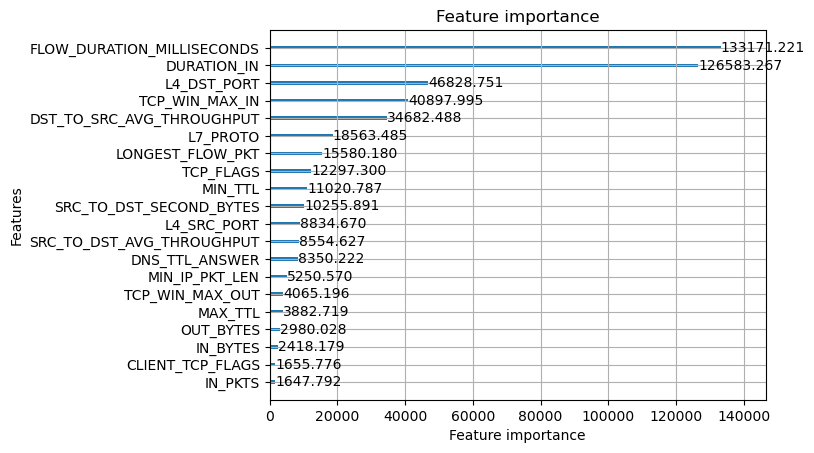

In [13]:
import matplotlib.pyplot as plt
import lightgbm as lgb

lgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.show()

In [14]:
import polars as pl

# Features + target
features = [
    # put your feature names here (excluding target)
]
target = "Label"

# Lazy loading
df_lazy = pl.scan_csv(
    "/Users/eldanizarifzada/Downloads/NF-UQ-NIDS-v2.csv"
).select(features + [target])

In [15]:
import polars as pl

# Lazy load CSV
df_lazy = pl.scan_csv("/Users/eldanizarifzada/Downloads/NF-UQ-NIDS-v2.csv")

# Assign to train/test using hash-based randomization
df_with_rand = df_lazy.with_columns(
    (pl.col(df_lazy.columns[0]).hash() % 10).alias("rand")  # hash first column
)

# Split without loading whole dataset
train_df = df_with_rand.filter(pl.col("rand") < 8)
test_df = df_with_rand.filter(pl.col("rand") >= 8)

# Collect only when needed
train_df = train_df.collect()
test_df = test_df.collect()

/var/folders/hb/5qplwbgn6kz_278njx67_1k40000gn/T/ipykernel_17622/3263719191.py:8: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  (pl.col(df_lazy.columns[0]).hash() % 10).alias("rand")  # hash first column


In [45]:
import polars as pl
import numpy as np
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

# 1. Define features and target
features = [
    'L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
    'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
    'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
    'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
    'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
    'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
    'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
    'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
    'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE'
]
target = 'Label'

# 2. Read a sample from CSV (adjust n_rows as per memory limits)
df_sample = pl.read_csv(
    "/Users/eldanizarifzada/Downloads/NF-UQ-NIDS-v2.csv",
    n_rows=100_000  # change to bigger if memory allows
).select(features + [target])

# 3. Identify categorical columns to encode
cat_cols = ['PROTOCOL']  # Add others if needed

# 4. Manual label encoding for categorical columns
for col in cat_cols:
    unique_vals = df_sample[col].unique().to_list()
    mapping = {val: i for i, val in enumerate(unique_vals)}
    arr = df_sample[col].to_numpy()
    mapped_arr = np.array([mapping.get(x, -1) for x in arr], dtype=np.int32)
    df_sample = df_sample.with_columns([
        pl.Series(col, mapped_arr)
    ])

# 5. Prepare features and target as numpy arrays for LightGBM
X = df_sample.select(features).to_numpy()
y = df_sample[target].to_numpy()

# 6. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 8. Define LightGBM parameters (CPU for compatibility)
params = {
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc'],
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'verbose': -1,
}

# 9. Train the model
model = lgb.train(
    params,
    train_data,
    num_boost_round=100,
    valid_sets=[train_data, test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)

# 10. Predict and evaluate
y_pred_prob = model.predict(X_test, num_iteration=model.best_iteration)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	training's binary_logloss: 0.0323254	training's auc: 0.999349	valid_1's binary_logloss: 0.0420592	valid_1's auc: 0.998228
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      6597
           1       0.99      0.99      0.99     13403

    accuracy                           0.99     20000
   macro avg       0.98      0.99      0.98     20000
weighted avg       0.99      0.99      0.99     20000

ROC AUC: 0.9982279718982188
